Rows: 568473
After clean rows: 568472
Example segment: PROD.Group1
Fitted: True
Fitted models for 49 segments out of 55
        week  avg_price  total_qty  ln_price  elasticity
0 2021-10-11   9.450000        3.0  2.246015    1.145564
1 2021-11-15   9.450000        2.0  2.246015    1.145564
2 2021-11-29   1.020000       12.0  0.019803   -4.894924
3 2022-01-03  18.745692      441.0  2.930964    0.894670
4 2022-01-10  23.281492     2439.0  3.147659   -0.127120
Segment: PROD.Group11


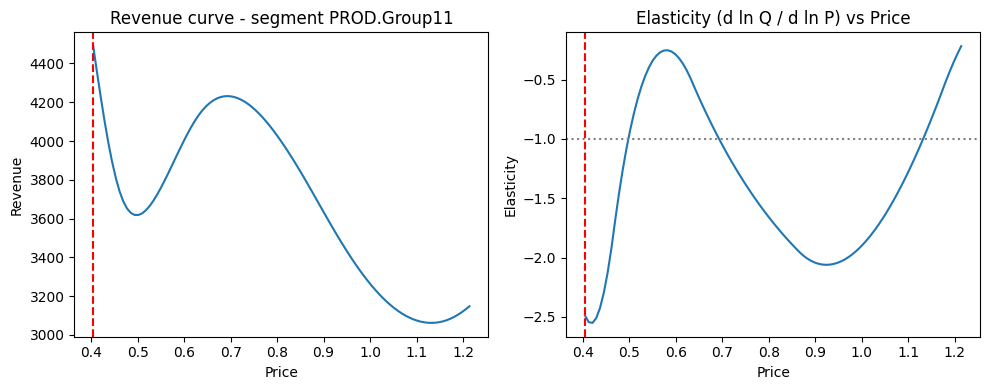

Saved recommendations to segment_price_elasticity_recommendations.csv


In [6]:
import warnings
warnings.filterwarnings("ignore")

!pip install pygam

import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from pygam import LinearGAM, s, f

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv(r"/content/Intuilize_MNSU_ACME_SalesData.csv", parse_dates=["OrderDate", "SalesDate"])

# Quick peek
print("Rows:", len(df))
df.head()

cols_needed = [
    "BranchID","OrderNumber","InvoiceNumber","LineNumber","OrderDate","SalesDate",
    "SalesPersonID","ProductID","ProductGroupID","CustomerID",
    "ExtPrice","ExtCost","SalesQty","UnitPrice","UnitCost","UOM","UnitSize"
]

df = df[cols_needed].copy()


df = df[(df["SalesQty"] > 0) & (df["UnitPrice"] > 0)]


df["price"] = df["UnitPrice"].astype(float)

df["quantity"] = df["SalesQty"].astype(float)


df["week"] = df["SalesDate"].dt.to_period("W").apply(lambda r: r.start_time)

print("After clean rows:", len(df))

prod_stats = df.groupby("ProductID").agg(
    avg_price = ("price","mean"),
    sd_price = ("price","std"),
    avg_qty = ("quantity","mean"),
    total_qty = ("quantity","sum"),
    product_group = ("ProductGroupID", "first"),
    unit_size = ("UnitSize", "first")
).reset_index()

prod_stats["sd_price"] = prod_stats["sd_price"].fillna(0.0)


use_group_as_segment = True
if use_group_as_segment and prod_stats["product_group"].notnull().any():
    prod_stats["segment"] = prod_stats["product_group"].astype(str)
else:
    # Option B: KMeans cluster products into ~20 segments
    k = 20
    clus_features = prod_stats[["avg_price","sd_price","avg_qty","total_qty"]].fillna(0.0)
    scaler = StandardScaler()
    Xc = scaler.fit_transform(clus_features)
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE).fit(Xc)
    prod_stats["segment"] = ["seg_"+str(int(x)) for x in km.labels_]


df = df.merge(prod_stats[["ProductID","segment"]], on="ProductID", how="left")


agg = df.groupby(["segment","week"]).apply(
    lambda g: pd.Series({
        "total_qty": g["quantity"].sum(),
        "avg_price": np.average(g["price"], weights=g["quantity"]) if g["quantity"].sum() > 0 else g["price"].mean(),
        "n_lines": len(g),
        "unique_products": g["ProductID"].nunique()
    })
).reset_index()


agg = agg.sort_values(["segment","week"])
agg["t"] = (agg["week"] - agg["week"].min()).dt.days  # linear time index
agg["month"] = agg["week"].dt.month
agg["weekday"] = agg["week"].dt.weekday


agg = agg[agg["total_qty"] > 0]
agg.head()


agg["ln_qty"] = np.log(agg["total_qty"])
agg["ln_price"] = np.log(agg["avg_price"])


le_month = LabelEncoder()
agg["month_enc"] = le_month.fit_transform(agg["month"].astype(str))


# 5. Modeling approach (per-segment GAM)
# We'll fit a LinearGAM that predicts ln_qty from:
# - s(ln_price) : smooth for price (this lets elasticity vary with price)
# - s(t) : smooth for time trend
# - f(month_enc) : factor for seasonal monthly effects
#
# Because we have multiple segments, we'll fit one GAM per segment.
# For performance, if you have lots of segments, parallelize or sample.

def fit_gam_for_segment(seg_df, max_iter=100):
    """
    Fit a small & interpretable GAM for a single segment.
    returns fitted model and X, y used for training
    """
    # Require at least some observations
    if len(seg_df) < 8:
        return None, None, None

    X = seg_df[["ln_price","t","month_enc"]].values
    y = seg_df["ln_qty"].values

    # Build a GAM: smooth ln_price, smooth time, factor month
    gam = LinearGAM(s(0, n_splines=20) + s(1, n_splines=8) + f(2)).gridsearch(X, y, progress=False)
    return gam, X, y

# Example: fit for a single segment to test
example_seg = agg["segment"].unique()[0]
print("Example segment:", example_seg)
seg_df = agg[agg["segment"] == example_seg]
gam_example, X_ex, y_ex = fit_gam_for_segment(seg_df)
print("Fitted:", gam_example is not None)

# 6. Fit models for all segments (parallelized)
segments = agg["segment"].unique()

def fit_one(seg):
    seg_df = agg[agg["segment"] == seg].copy()
    model, X, y = fit_gam_for_segment(seg_df)
    return seg, model, seg_df

results = Parallel(n_jobs=4)(delayed(fit_one)(s) for s in segments)

# Keep models in a dict
models = {seg: model for (seg, model, seg_df) in results if model is not None}
seg_dfs = {seg: seg_df for (seg, model, seg_df) in results if model is not None}
print(f"Fitted models for {len(models)} segments out of {len(segments)}")

# 7. Elasticity: compute derivative of ln(Q) w.r.t ln(P)
# For a GAM predicting ln_qty, the instantaneous elasticity at X is derivative d ln_qty / d ln_price.
# pyGAM provides derivatives() for smooth terms. We'll compute the numerical derivative of the
# whole GAM prediction w.r.t the ln_price variable by evaluating model predictions at small price variations.

def elasticity_at(gam, X_row, eps=1e-4):
    """
    Estimate elasticity (d ln_qty / d ln_price) at a given row X using finite differences.
    X_row: 1D array [ln_price, t, month_enc]
    Returns: elasticity (float)
    """
    X_row = X_row.reshape(1, -1)
    # baseline predicted ln_qty
    y0 = gam.predict(X_row)[0]
    # perturb ln_price by +eps
    Xp = X_row.copy()
    Xp[0,0] += eps
    yp = gam.predict(Xp)[0]
    # finite diff d ln_qty / d ln_price ≈ (yp - y0) / eps
    deriv = (yp - y0) / eps
    return float(deriv)

# Quick test: compute elasticity across observed rows for one segment
g = gam_example
if g is not None:
    ex_df = seg_df.copy()
    Xrows = ex_df[["ln_price","t","month_enc"]].values
    ex_df["elasticity"] = [elasticity_at(g, Xrows[i]) for i in range(len(Xrows))]
    print(ex_df[["week","avg_price","total_qty","ln_price","elasticity"]].head())

# 8. Segment-level summaries: average elasticity and confidence
segment_summary = []
for seg, gam in models.items():
    seg_df = seg_dfs[seg]
    Xrows = seg_df[["ln_price","t","month_enc"]].values
    elasticities = [elasticity_at(gam, Xrows[i]) for i in range(len(Xrows))]
    seg_summary = {
        "segment": seg,
        "n_periods": len(seg_df),
        "mean_price": float(seg_df["avg_price"].mean()),
        "median_price": float(seg_df["avg_price"].median()),
        "mean_elasticity": float(np.mean(elasticities)),
        "std_elasticity": float(np.std(elasticities))
    }
    segment_summary.append(seg_summary)

seg_summary_df = pd.DataFrame(segment_summary).sort_values("mean_elasticity")
seg_summary_df.head(20)

# 9. Find revenue-optimal price for each segment via grid search
# Revenue R = price * quantity
# quantity predicted by exponentiating predicted ln_qty: Q_hat = exp(gam.predict(X_with_price))
# For each segment we take typical covariate context (e.g., median t, median month_enc),
# then sweep price around current median price to find price maximizing revenue.

def find_optimal_price_for_segment(gam, seg_df, price_grid_pct=0.5, n_points=101):
    """
    price_grid_pct: +/- fraction around current median price (e.g., 0.5 => from -50% to +50%)
    """
    median_price = float(seg_df["avg_price"].median())
    lower = median_price * (1 - price_grid_pct)
    upper = median_price * (1 + price_grid_pct)
    prices = np.linspace(lower, upper, n_points)

    # Use representative covariates: median t, most common month_enc
    median_t = float(seg_df["t"].median())
    mode_month = int(seg_df["month_enc"].mode().iloc[0])

    revenues = []
    elasticities = []
    for p in prices:
        ln_p = np.log(p)
        Xrep = np.array([[ln_p, median_t, mode_month]])
        lnq = gam.predict(Xrep)[0]
        q = np.exp(lnq)
        revenues.append(p * q)
        # elasticity at this point
        el = elasticity_at(gam, Xrep[0])
        elasticities.append(el)
    # Select max revenue
    idx = int(np.argmax(revenues))
    return {
        "median_price": median_price,
        "optimal_price": float(prices[idx]),
        "optimal_revenue": float(revenues[idx]),
        "optimal_elasticity": float(elasticities[idx]),
        "price_grid": prices,
        "revenues": revenues,
        "elasticities": elasticities
    }

# Compute for all segments
opt_results = {}
for seg, gam in models.items():
    seg_df = seg_dfs[seg]
    opt = find_optimal_price_for_segment(gam, seg_df, price_grid_pct=0.5, n_points=101)
    opt_results[seg] = opt

# Merge opt into summary
opt_rows = []
for seg, opt in opt_results.items():
    opt_rows.append({
        "segment": seg,
        "median_price": opt["median_price"],
        "optimal_price": opt["optimal_price"],
        "optimal_elasticity": opt["optimal_elasticity"],
        "revenue_ratio_vs_current": opt["optimal_revenue"] / (opt["median_price"] * np.exp(models[seg].predict([[np.log(opt['median_price']), seg_dfs[seg]['t'].median(), seg_dfs[seg]['month_enc'].mode()[0]]])[0]))
    })
opt_df = pd.DataFrame(opt_rows)
final = seg_summary_df.merge(opt_df, on="segment", how="left")
final = final.sort_values("mean_elasticity")
final.head(20)

# 10. Plot example: elasticity and revenue curve for one chosen segment
seg = final["segment"].iloc[0]
print("Segment:", seg)
opt = opt_results[seg]
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(opt["price_grid"], opt["revenues"])
plt.axvline(opt["optimal_price"], color="red", linestyle="--")
plt.title(f"Revenue curve - segment {seg}")
plt.xlabel("Price")
plt.ylabel("Revenue")

plt.subplot(1,2,2)
plt.plot(opt["price_grid"], opt["elasticities"])
plt.axhline(-1, color="grey", linestyle=":")
plt.axvline(opt["optimal_price"], color="red", linestyle="--")
plt.title("Elasticity (d ln Q / d ln P) vs Price")
plt.xlabel("Price")
plt.ylabel("Elasticity")
plt.tight_layout()
plt.show()

# 11. Save results (per-segment recommended price)
final.to_csv("segment_price_elasticity_recommendations.csv", index=False)
print("Saved recommendations to segment_price_elasticity_recommendations.csv")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
